<a href="https://colab.research.google.com/github/MonishDY/AI-Track/blob/main/Module%202%20-%20Feature%20Engineering/Capstone%20Project/MonishDY_230701195_Capstone_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Loan Default Prediction Using Feature Engineering and Feature Selection**

## **Problem Statement**

A financial institution wants to build a machine learning model to predict whether a customer will default on a loan. The organization has collected customer demographic, financial, behavioral, and transaction-related data.
However, the dataset contains:
- Missing values in numeric and categorical columns
- Outliers in income and loan amount
- Class imbalance because only a small percentage of customers default
- Highly correlated features
- Irrelevant or low-variance features
- Time-based records that require careful validation
- Customer group information that may cause data leakage


Your task is to perform a complete feature engineering and feature selection pipeline before training and evaluating machine learning models.

## **Dataset Description**

Assume the dataset is named:
`loan_default_dataset.csv`

**Dataset Size**
- Rows: 10,000 customers
- Columns: 28 features + 1 target column



## **Feature Columns**

| Column Name | Type | Description |
|-------------|------|-------------|
| **customer_id** | ID | Unique customer identifier |
| **application_date** | Date | Date of loan application |
| **branch_id** | Categorical | Bank branch where loan was issued |
| **customer_group_id** | Categorical | Group/family/business identifier |
| **age** | Numerical | Age of applicant |
| **gender** | Categorical | Male, Female, Other |
| **marital_status** | Categorical | Single, Married, Divorced |
| **education_level** | Categorical | School, Graduate, Postgraduate |
| **employment_type** | Categorical | Salaried, Self-employed, Unemployed |
| **annual_income** | Numerical | Annual income of applicant |
| **monthly_expenses** | Numerical | Average monthly expenses |
| **loan_amount** | Numerical | Loan amount requested |
| **loan_tenure_months** | Numerical | Loan repayment period |
| **interest_rate** | Numerical | Loan interest rate |
| **credit_score** | Numerical | Credit score of applicant |
| **existing_loans_count** | Numerical | Number of existing loans |
| **credit_card_utilization** | Numerical | Credit card usage percentage |
| **late_payment_count** | Numerical | Number of previous late payments |
| **bank_balance** | Numerical | Current bank balance |
| **savings_account_balance** | Numerical | Savings account balance |
| **transaction_frequency** | Numerical | Monthly transaction count |
| **avg_transaction_value** | Numerical | Average transaction amount |
| **last_payment_delay_days** | Numerical | Delay in most recent payment |
| **property_ownership** | Categorical | Own, Rent, Family Owned |
| **city_tier** | Categorical | Tier 1, Tier 2, Tier 3 |
| **has_insurance** | Categorical | Yes, No |
| **loan_purpose** | Categorical | Education, Home, Business, Personal |
| **risk_segment** | Categorical | Low, Medium, High |

## **Target Variable**

| Column Name | Type | Description |
|-------------|------|-------------|
| **default_status** | Binary (Target) | **Target variable:** 1 = Customer defaulted, 0 = Customer did not default |

---


## **Section A: Data Understanding and Preprocessing**

In [1]:
# Data processing
import pandas as pd

### **Task A1: Load and inspect the dataset**

In [2]:
# Load Dataset
path = r"https://raw.githubusercontent.com/MonishDY/AI-Track/refs/heads/main/Module%202%20-%20Feature%20Engineering/Capstone%20Project/loan_default_dataset.csv"
df = pd.read_csv(path)

In [3]:
# Display top 5 rows
df.head()

,customer_id,application_date,branch_id,customer_group_id,age,gender,marital_status,education_level,employment_type,annual_income,...,property_ownership,city_tier,has_insurance,loan_purpose,risk_segment,income_to_loan_ratio,debt_to_income_ratio,annual_income_duplicate,low_variance_flag,default_status
0,100001,2023-03-07,BR017,G00086,55.0,Male,Single,Graduate,Self-employed,101705.21,...,Family Owned,Tier 2,No,Personal,Low,0.6736,1.5871,101258.26,0,0
1,100002,2024-07-18,BR011,G01802,58.0,Male,Single,Postgraduate,Salaried,90000.00,...,Own,Tier 3,No,Personal,Medium,0.3097,1.4739,89503.62,0,0
2,100003,2024-04-22,BR027,G00535,43.0,Male,Single,School,Self-employed,90000.00,...,Rent,Tier 2,Yes,Business,Medium,0.4366,1.2393,88647.76,0,0
3,100004,2023-11-17,BR034,G01779,25.0,Female,Married,Postgraduate,Salaried,NaN,...,Own,Tier 1,Yes,Education,Medium,1.8000,1.0567,88836.33,0,0
4,100005,2023-11-13,BR014,G01412,58.0,Female,Single,Graduate,Self-employed,90000.00,...,Rent,Tier 3,Yes,Education,Low,1.6769,1.2630,88659.90,0,0


In [4]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 33)


In [5]:
# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              10000 non-null  int64  
 1   application_date         10000 non-null  object 
 2   branch_id                10000 non-null  object 
 3   customer_group_id        10000 non-null  object 
 4   age                      9732 non-null   float64
 5   gender                   9781 non-null   object 
 6   marital_status           10000 non-null  object 
 7   education_level          10000 non-null  object 
 8   employment_type          9462 non-null   object 
 9   annual_income            9193 non-null   float64
 10  monthly_expenses         9400 non-null   float64
 11  loan_amount              9610 non-null   float64
 12  loan_tenure_months       10000 non-null  int64  
 13  interest_rate            10000 non-null  float64
 14  credit_sc

In [6]:
# Numerical column variables
num_cols = df.select_dtypes(include="number").columns
print("Numerical Features:\n")

for i, col in enumerate(list(num_cols)):
  print(f"{i+1}. {col}")

Numerical Features:

1. customer_id
2. age
3. annual_income
4. monthly_expenses
5. loan_amount
6. loan_tenure_months
7. interest_rate
8. credit_score
9. existing_loans_count
10. credit_card_utilization
11. late_payment_count
12. bank_balance
13. savings_account_balance
14. transaction_frequency
15. avg_transaction_value
16. last_payment_delay_days
17. income_to_loan_ratio
18. debt_to_income_ratio
19. annual_income_duplicate
20. low_variance_flag
21. default_status


In [7]:
# Categorical column variables
cat_cols = df.select_dtypes(include=["object"]).columns
print("Categorical Features:\n")

for i, col in enumerate(list(cat_cols)):
  print(f"{i+1}. {col}")

Categorical Features:

1. application_date
2. branch_id
3. customer_group_id
4. gender
5. marital_status
6. education_level
7. employment_type
8. property_ownership
9. city_tier
10. has_insurance
11. loan_purpose
12. risk_segment


In [8]:
# Missing value percentage
missing = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
missing[missing > 0].sort_values(ascending=False)

Missing Value Percentage:


,0
credit_score,10.85
annual_income,8.07
bank_balance,6.91
monthly_expenses,6.00
employment_type,5.38
avg_transaction_value,4.23
loan_amount,3.90
transaction_frequency,3.26
risk_segment,3.17
loan_purpose,2.94


In [9]:
# Target class distribution
print("Target Class Distribution:")
df["default_status"].value_counts()

Target Class Distribution:


,count
default_status,
0,9200
1,800


In [10]:
# Percentage of Target Distribution
print("Target Class Distribution (%):")
df["default_status"].value_counts(normalize=True) * 100

Target Class Distribution (%):


,proportion
default_status,
0,92.0
1,8.0


In [11]:
# Find Duplicate records
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 5


In [12]:
# Drop duplicates
df.drop_duplicates(inplace=True)
df.shape

(9995, 33)

### **Task A2: Identify feature types**


In [13]:
# List of Numerical Features
numerical_features = [
    "age",
    "annual_income",
    "monthly_expenses",
    "loan_amount",
    "loan_tenure_months",
    "interest_rate",
    "credit_score",
    "existing_loans_count",
    "credit_card_utilization",
    "late_payment_count",
    "bank_balance",
    "savings_account_balance",
    "transaction_frequency",
    "avg_transaction_value",
    "last_payment_delay_days"
]

print("Numerical Features:\n")
numerical_features

Numerical Features:



['age',
 'annual_income',
 'monthly_expenses',
 'loan_amount',
 'loan_tenure_months',
 'interest_rate',
 'credit_score',
 'existing_loans_count',
 'credit_card_utilization',
 'late_payment_count',
 'bank_balance',
 'savings_account_balance',
 'transaction_frequency',
 'avg_transaction_value',
 'last_payment_delay_days']

In [14]:
# List of Categorical Features
categorical_features = [
    "branch_id",
    "gender",
    "marital_status",
    "education_level",
    "employment_type",
    "property_ownership",
    "city_tier",
    "has_insurance",
    "loan_purpose",
    "risk_segment"
]

print("Categorical Features:\n")
categorical_features

Categorical Features:



['branch_id',
 'gender',
 'marital_status',
 'education_level',
 'employment_type',
 'property_ownership',
 'city_tier',
 'has_insurance',
 'loan_purpose',
 'risk_segment']

In [15]:
# List of Date / Time Feature
date_feature = ["application_date"]

print("Date Feature:\n")
date_feature

Date Feature:



['application_date']

In [16]:
# List of ID / Group Feature
id_group_features = [
    "customer_id",
    "customer_group_id"
]

print("ID / Group Features:\n")
id_group_features

ID / Group Features:



['customer_id', 'customer_group_id']

In [17]:
# Target Column
target = ["default_status"]

print("Target Feature:")
target

Target Feature:


['default_status']

---

## **Section B: Missing Value Treatment**

In [18]:
# Standardization
from sklearn.preprocessing import StandardScaler

# Import Imputation Methods
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Regression Imputation
from sklearn.linear_model import LinearRegression

In [19]:
# Check for missing / null values
round(df.isnull().sum() * 100 / len(df), 2)

,0
customer_id,0.00
application_date,0.00
branch_id,0.00
customer_group_id,0.00
age,2.68
gender,2.19
marital_status,0.00
education_level,0.00
employment_type,5.38
annual_income,8.07


### **Task B1: Simple Imputation**

In [20]:
# Mean Imputation
mean_cols = ["age", "loan_tenure_months", "interest_rate"]

mean_imputer = SimpleImputer(strategy="mean")
df[mean_cols] = mean_imputer.fit_transform(df[mean_cols])

# Check for null values
df[mean_cols].isnull().sum()

,0
age,0
loan_tenure_months,0
interest_rate,0


In [21]:
# Median Imputation
median_cols = ["annual_income", "loan_amount", "bank_balance", "monthly_expenses"]

median_imputer = SimpleImputer(strategy="median")
df[median_cols] = median_imputer.fit_transform(df[median_cols])

df[median_cols].isnull().sum()

,0
annual_income,0
loan_amount,0
bank_balance,0
monthly_expenses,0


In [22]:
# Mode Imputation
mode_cols = ["employment_type", "gender", "marital_status", "loan_purpose", "risk_segment", "property_ownership"]

mode_imputer = SimpleImputer(strategy="most_frequent")
df[mode_cols] = mode_imputer.fit_transform(df[mode_cols])

df[mode_cols].isnull().sum()

,0
employment_type,0
gender,0
marital_status,0
loan_purpose,0
risk_segment,0
property_ownership,0


### **Task B2: Advanced Imputation Techniques**

In [23]:
# Scaled the data
knn_cols = ["bank_balance", "savings_account_balance"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[knn_cols])

# KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5)
scaled_imputed = knn_imputer.fit_transform(scaled_data)

df[knn_cols] = scaler.inverse_transform(scaled_imputed)
df[knn_cols].isnull().sum()

,0
bank_balance,0
savings_account_balance,0


#### **Interpretation**

KNN Imputation fills missing values using the nearest neighbors. Scaling is important because KNN uses distance calculations. It preserves relationships better than simple imputation but is computationally expensive.

* **Why scaling is needed before KNN imputation:** Scaling ensures all features contribute equally to distance calculations.
* **How nearest neighbors estimate missing values:** KNN fills missing values using the average (or majority vote) of the nearest similar data points.


In [24]:
# Regression Imputation
features = ["annual_income", "loan_amount", "bank_balance", "monthly_expenses"]

train = df[df["credit_score"].notna()].dropna(subset=features)
test = df[df["credit_score"].isna()].dropna(subset=features)

model = LinearRegression()
model.fit(train[features], train["credit_score"])

df.loc[test.index, "credit_score"] = model.predict(test[features])
df["credit_score"].isnull().sum()

np.int64(0)

#### **Interpretation**

Regression Imputation predicts missing values using other related features. It is more accurate than simple imputation but may reduce data variability.

* **Feature imputed:** `credit_score`.
* **Predictors used:** `annual_income`, `loan_amount`, `bank_balance`, and `monthly_expenses`.
* **Limitation of regression imputation:** It may underestimate variability and assumes a linear relationship between predictors and the missing feature.


In [25]:
# Iterative Imputation - MICE
mice_cols = ["loan_amount", "transaction_frequency", "avg_transaction_value", "last_payment_delay_days"]

mice = IterativeImputer(random_state=42)
df[mice_cols] = mice.fit_transform(df[mice_cols])

df[mice_cols].isnull().sum()

,0
loan_amount,0
transaction_frequency,0
avg_transaction_value,0
last_payment_delay_days,0


#### **Interpretation**

MICE estimates missing values by repeatedly modeling each feature using the remaining features. It handles multiple missing columns well but requires more computation.

* **How each missing feature is modeled:** Each feature with missing values is iteratively predicted using the other features as predictors.
* **Why MICE is useful:** It captures relationships among multiple variables, producing more accurate imputations when many columns have missing values.


In [26]:
# Forward Fill and Backward Fill
df = df.sort_values("application_date")
time_cols = ["application_date"]

df[time_cols] = df[time_cols].ffill().bfill()
df[time_cols].isnull().sum()

,0
application_date,0


#### **Interpretation**

Forward and Backward Fill are suitable for time-ordered data. They should not be used on randomly ordered datasets as they may introduce incorrect values.

* **Why forward/backward fill is suitable for time-ordered data:** It preserves temporal continuity by using the previous or next observation.
* **Why it should not be used on unordered data:** It can introduce incorrect values because there is no meaningful order between observations.


#### **Comparison of Advanced Imputation Techniques**

- **KNN Imputation**
  - Uses nearest neighbors to fill missing values.
  - Requires feature scaling.

- **Regression Imputation**
  - Predicts missing values using other features.
  - May reduce data variability.

- **Iterative Imputer (MICE)**
  - Uses all features iteratively for imputation.
  - Suitable for multiple missing columns.

- **Forward Fill & Backward Fill**
  - Fills missing values using previous or next observations.
  - Best for time-ordered data.

---


## **Section C: Data Transformation and Scaling**

### **Task C1: Apply Z-score Standardization**

In [27]:
# Apply Z-Score Standardization
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df.head()

,customer_id,application_date,branch_id,customer_group_id,age,gender,marital_status,education_level,employment_type,annual_income,...,property_ownership,city_tier,has_insurance,loan_purpose,risk_segment,income_to_loan_ratio,debt_to_income_ratio,annual_income_duplicate,low_variance_flag,default_status
6301,106302,2023-01-01,BR026,G01844,0.618736,Male,Married,Graduate,Salaried,-0.381375,...,Own,Tier 2,Yes,Personal,Low,0.5705,1.2510,89785.44,0,0
6905,106906,2023-01-01,BR008,G00926,0.136001,Female,Single,Postgraduate,Salaried,0.129852,...,Own,Tier 1,Yes,Personal,Low,0.5061,1.2388,100997.92,0,0
2315,102316,2023-01-01,BR003,G02191,1.101471,Male,Married,Graduate,Self-employed,-0.381375,...,Rent,Tier 2,Yes,Education,Low,1.8000,1.2222,89500.63,0,0
7362,107363,2023-01-01,BR020,G00525,-0.057092,Female,Married,Postgraduate,Self-employed,-0.381375,...,Rent,Tier 1,No,Personal,Medium,1.7386,0.7625,88285.11,0,0
2441,102442,2023-01-01,BR023,G00929,-1.601843,Female,Single,School,Salaried,-0.381375,...,Own,Tier 1,No,Business,Low,0.3980,1.5165,87823.22,0,0


#### **Why Scaling is Important?**

- **KNN:** Distance-based algorithm; scaling prevents larger values from dominating.
- **Logistic Regression:** Improves convergence and model performance.
- **Ridge Regression:** Ensures fair L2 regularization across features.
- **Lasso Regression:** Ensures fair L1 regularization across features.
- **SVM:** Improves decision boundary by treating all features equally.
- **Distance-Based Algorithms:** All features contribute equally to distance calculations.

---

## **Section D: Handling Imbalanced Data**

In [28]:
# Import sampling techniques
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

### **Task D1: Analyze class imbalance**

In [29]:
# Analyze class imbalances
print("Class Distribution:")
print(df["default_status"].value_counts())

print("\nPercentage Distribution:")
print(df["default_status"].value_counts(normalize=True) * 100)

Class Distribution:
default_status
0    9195
1     800
Name: count, dtype: int64

Percentage Distribution:
default_status
0    91.995998
1     8.004002
Name: proportion, dtype: float64


#### **Why Accuracy is Not Reliable?**

- The dataset is **imbalanced** (92% non-default, 8% default).
- A model can achieve **92% accuracy** by predicting every customer as **non-default**.
- Such a model fails to identify actual **default** cases, making the high accuracy misleading.
- **Precision, Recall, F1-Score, and ROC-AUC** are more suitable metrics for evaluating imbalanced classification problems.

In [30]:
# Random Oversampling
X = df.drop("default_status", axis=1)
y = df["default_status"]

ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X, y)

print(y_over.value_counts())
X_over.head()

default_status
0    9195
1    9195
Name: count, dtype: int64


,customer_id,application_date,branch_id,customer_group_id,age,gender,marital_status,education_level,employment_type,annual_income,...,last_payment_delay_days,property_ownership,city_tier,has_insurance,loan_purpose,risk_segment,income_to_loan_ratio,debt_to_income_ratio,annual_income_duplicate,low_variance_flag
0,106302,2023-01-01,BR026,G01844,0.618736,Male,Married,Graduate,Salaried,-0.381375,...,-0.684993,Own,Tier 2,Yes,Personal,Low,0.5705,1.2510,89785.44,0
1,106906,2023-01-01,BR008,G00926,0.136001,Female,Single,Postgraduate,Salaried,0.129852,...,-0.876915,Own,Tier 1,Yes,Personal,Low,0.5061,1.2388,100997.92,0
2,102316,2023-01-01,BR003,G02191,1.101471,Male,Married,Graduate,Self-employed,-0.381375,...,0.658463,Rent,Tier 2,Yes,Education,Low,1.8000,1.2222,89500.63,0
3,107363,2023-01-01,BR020,G00525,-0.057092,Female,Married,Postgraduate,Self-employed,-0.381375,...,-0.301148,Rent,Tier 1,No,Personal,Medium,1.7386,0.7625,88285.11,0
4,102442,2023-01-01,BR023,G00929,-1.601843,Female,Single,School,Salaried,-0.381375,...,-0.301148,Own,Tier 1,No,Business,Low,0.3980,1.5165,87823.22,0


In [31]:
# Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X, y)

print(y_under.value_counts())
X_under.head()

default_status
0    800
1    800
Name: count, dtype: int64


,customer_id,application_date,branch_id,customer_group_id,age,gender,marital_status,education_level,employment_type,annual_income,...,last_payment_delay_days,property_ownership,city_tier,has_insurance,loan_purpose,risk_segment,income_to_loan_ratio,debt_to_income_ratio,annual_income_duplicate,low_variance_flag
3267,103268,2024-05-18,BR029,G00354,-1.794937,Male,Married,School,Salaried,-0.381375,...,-1.068837,Rent,Tier 1,No,Home,Medium,0.7299,0.9407,89170.98,0
5608,105609,2024-03-19,BR006,G01349,0.522189,Other,Married,Graduate,Self-employed,-0.381375,...,0.082696,Rent,Tier 2,Yes,Business,Medium,0.4955,1.0031,89140.52,0
8458,108459,2023-10-27,BR014,G00480,0.908377,Female,Single,Graduate,Salaried,-0.381375,...,0.082696,Rent,Tier 1,Yes,Personal,Low,1.8000,1.2222,90964.37,0
8196,108197,2023-09-01,BR010,G01936,0.039455,Female,Married,School,Salaried,-0.307049,...,-0.301148,Own,Tier 2,No,Personal,Low,1.8391,0.7613,92744.39,0
4612,104613,2024-07-28,BR002,G02481,2.356580,Male,Married,Postgraduate,Salaried,1.373966,...,-1.068837,Own,Tier 3,No,Home,Low,1.0119,1.4224,137204.63,0


#### **Risk of Undersampling**

- Removes majority class samples.
- May discard useful information and reduce model performance.
- Can lead to underfitting if too much majority class data is removed.

In [32]:
# SMOTE
X = df.drop("default_status", axis=1)
X = X.select_dtypes(include=["number"])

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print(y_smote.value_counts())
X_smote.head()

default_status
0    9195
1    9195
Name: count, dtype: int64


,customer_id,age,annual_income,monthly_expenses,loan_amount,loan_tenure_months,interest_rate,credit_score,existing_loans_count,credit_card_utilization,late_payment_count,bank_balance,savings_account_balance,transaction_frequency,avg_transaction_value,last_payment_delay_days,income_to_loan_ratio,debt_to_income_ratio,annual_income_duplicate,low_variance_flag
0,106302,0.618736,-0.381375,-0.5963,-0.100163,-0.549383,-1.333930,0.004441,0.695825,-0.038285,-0.038039,1.168495,-0.808698,0.271216,0.272703,-0.684993,0.5705,1.2510,89785.44,0
1,106906,0.136001,0.129852,-0.5963,0.349871,-0.549383,0.572026,-1.382291,0.695825,-1.172748,-0.038039,0.697734,0.148894,-1.060453,-0.068137,-0.876915,0.5061,1.2388,100997.92,0
2,102316,1.101471,-0.381375,-0.5963,-1.140257,-1.851667,-1.097721,1.807193,-1.110844,-0.397993,-0.983820,1.373563,-0.522793,-1.060453,-0.715847,0.658463,1.8000,1.2222,89500.63,0
3,107363,-0.057092,-0.381375,-0.5963,-1.123212,1.404043,-0.499056,-0.986082,-0.207509,-0.724497,1.853522,0.477777,-1.028797,-2.313788,1.350779,-0.301148,1.7386,0.7625,88285.11,0
4,102442,-1.601843,-0.381375,-0.5963,0.559483,-0.549383,1.374319,0.935533,0.695825,-1.936435,-0.983820,-0.648320,-1.307755,0.662884,-0.715847,-0.301148,0.3980,1.5165,87823.22,0


#### **SMOTE**
**How does SMOTE create synthetic samples?**  
- SMOTE creates synthetic minority class samples by interpolating between a sample and its nearest minority class neighbors.

**Why is SMOTE better than simple oversampling?**  
- It generates new synthetic samples instead of duplicating existing ones, reducing overfitting.

**What is one limitation of SMOTE?**  
- It may generate noisy or overlapping samples near class boundaries.

### **Interpretation**

- The loan default dataset is imbalanced, making accuracy an unreliable metric because a model can achieve high accuracy by predicting only the majority class. - Random Oversampling balances the dataset by duplicating minority class samples, but it may lead to overfitting.
- Random Undersampling reduces the majority class, which speeds up training but may remove useful information.
- SMOTE generates synthetic minority class samples using the nearest neighbors instead of simple duplication, resulting in better class representation and improved generalization.
- Therefore, SMOTE is the preferred technique for handling class imbalance in this case study.

## **Section E: Regularization**

In [33]:
# Test Split and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Regularization
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import LogisticRegression

### **Task E1: Apply Ridge Regression / Ridge Classifier**

In [34]:
# Ridge Regularization
X = df.drop("default_status", axis=1)
X = X.select_dtypes(include=["number"])
y = df["default_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ridge = RidgeClassifier(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.9175


**Meaning of L2 penalty**
- L2 penalty adds the squared values of coefficients to the loss function, shrinking coefficients toward zero.

**Effect of increasing alpha**
- A larger alpha increases regularization, shrinking coefficients more and simplifying the model.

**Why Ridge reduces overfitting**
- By reducing large coefficient values, Ridge lowers model complexity and improves generalization.

In [35]:
# Lasso Regularization
lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    random_state=42
)

lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.921


**Meaning of L1 penalty**
- L1 penalty adds the absolute values of coefficients to the loss function.

**Why Lasso can perform feature selection**
- Lasso can shrink some coefficients exactly to zero, effectively removing unimportant features.

**Difference between Ridge and Lasso**
- Ridge (L2) shrinks coefficients but rarely makes them zero, while Lasso (L1) can shrink coefficients to zero and perform feature selection.

---

## **Section F: Cross-Validation Techniques**

In [36]:
# Import Cross Validation techniques
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    LeavePOut,
    ShuffleSplit,
    TimeSeriesSplit,
    GroupKFold,
    RepeatedKFold,
    cross_val_score
)

In [37]:
# To explain Cross Validation we have taken a sample of the dataset
X_small = X.sample(n=1000, random_state=42)
y_small = y.loc[X_small.index]

groups_small = df.loc[X_small.index, "customer_group_id"]
model = RidgeClassifier(alpha=1.0)

### **Task F1: K-Fold Cross-Validation**

In [38]:
# K-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_small, y_small, cv=kf)

print("K-Fold CV Accuracy: ", round(scores.mean(), 4))

K-Fold CV Accuracy:  0.919


### **Task F2: Stratified K-Fold**

In [39]:
# Stratified K-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_small, y_small, cv=skf)

print("Stratified K-Fold CV Accuracy: ", round(scores.mean(), 4))

Stratified K-Fold CV Accuracy:  0.919


### **Task F3: LOOCV**

In [40]:
# LOOCV
loo = LeaveOneOut()
scores = cross_val_score(model, X_small, y_small, cv=loo)

print("LOOCV Accuracy: ", round(scores.mean(), 4))

LOOCV Accuracy:  0.919


### **Task F4: Leave-P-Out**

In [41]:
# Leave P out
lpo = LeavePOut(p=2)
scores = cross_val_score(model, X_small.head(20), y_small.head(20), cv=lpo)

print("Leave P-out CV Accuracy: ", round(scores.mean(), 4))

Leave P-out CV Accuracy:  1.0


### **Task F5: Shuffle Split**

In [42]:
# Shuffle Split CV
ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
scores = cross_val_score(model, X_small, y_small, cv=ss)

print("Shuffle Split CV Accuracy: ", round(scores.mean(), 4))

Shuffle Split CV Accuracy:  0.899


### **Task F6: Time Series Split**

In [43]:
# Time Series Split
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X_small, y_small, cv=tscv)

print("Time Series Split CV Accuracy: ", round(scores.mean(), 4))

Time Series Split CV Accuracy:  0.9193


### **Task F7: Group K-Fold**

In [44]:
# Group K-Fold CV
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X_small, y_small, cv=gkf, groups=groups_small)

print("Group K-Fold CV Accuracy: ", round(scores.mean(), 4))

Group K-Fold CV Accuracy:  0.919


### **Task F8: Repeated K-Fold**

In [45]:
# Repeated K-Fold CV
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
scores = cross_val_score(model, X_small, y_small, cv=rkf)

print("Repeated K-Fold CV Accuracy: ", round(scores.mean(), 4))

Repeated K-Fold CV Accuracy:  0.919


#### **Suitable Cross-Validation Techniques**

- **K-Fold:** Suitable for general machine learning datasets.
- **Stratified K-Fold:** Suitable for imbalanced classification datasets.
- **Leave-One-Out (LOOCV):** Suitable for very small datasets.
- **Leave-P-Out:** Suitable for very small datasets where multiple train-test combinations are needed.
- **Shuffle Split:** Suitable for random train-test evaluation with multiple splits.
- **Time Series Split:** Suitable for time-dependent or chronological data.
- **Group K-Fold:** Suitable when samples belong to the same group and data leakage must be avoided.
- **Repeated K-Fold:** Suitable for obtaining a more reliable estimate of model performance by repeating K-Fold with different random splits.

---

## **Section G: Feature Selection**

In [46]:
# Filter Methods
from sklearn.feature_selection import VarianceThreshold

# Wrapper Methods
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Embedded Methods
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import ElasticNet
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

# Data visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

## **Task G1: Filter Methods**

- Variance Threshold removes low-variance features.
- Correlation-Based Selection selects features highly correlated with the target.

In [47]:
# Variance Threshold
selector = VarianceThreshold(threshold=0.1)
X_var = selector.fit_transform(X)

X.columns[selector.get_support()].tolist()

['customer_id',
 'age',
 'annual_income',
 'monthly_expenses',
 'loan_amount',
 'loan_tenure_months',
 'interest_rate',
 'credit_score',
 'existing_loans_count',
 'credit_card_utilization',
 'late_payment_count',
 'bank_balance',
 'savings_account_balance',
 'transaction_frequency',
 'avg_transaction_value',
 'last_payment_delay_days',
 'income_to_loan_ratio',
 'debt_to_income_ratio',
 'annual_income_duplicate']

In [48]:
# Correlation based selection
corr = X.corrwith(y).abs()
selected = corr[corr > 0.1]

print(selected.sort_values(ascending=False))

late_payment_count    0.251361
credit_score          0.186595
dtype: float64


### **Task G2: Wrapper Methods**


In [49]:
# Forward Selection
model = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction="forward",
    cv=5
)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]
print("Selected Features:\n")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

Selected Features:

1. age
2. credit_score
3. existing_loans_count
4. credit_card_utilization
5. late_payment_count


In [50]:
# Recursive Feature Elimination
model = LogisticRegression(max_iter=1000)

rfe = RFE(
    estimator=model,
    n_features_to_select=5
)

rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

1. monthly_expenses
2. credit_score
3. credit_card_utilization
4. late_payment_count
5. income_to_loan_ratio


**Why exhaustive feature selection is computationally expensive?**

* It evaluates **every possible combination of features** to find the best subset.
* As the number of features increases, the number of combinations grows exponentially, making it slow and computationally expensive.


### **Task G3: Embedded Methods**

In [51]:
# ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)

selector = SelectFromModel(model)
selector.fit(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))

Selected Features: ['late_payment_count']


In [52]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X, y)

importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
credit_score,0.351571
late_payment_count,0.288114
credit_card_utilization,0.175490
bank_balance,0.045895
debt_to_income_ratio,0.044526
savings_account_balance,0.034848
monthly_expenses,0.012905
annual_income,0.011770
customer_id,0.010600
transaction_frequency,0.007194


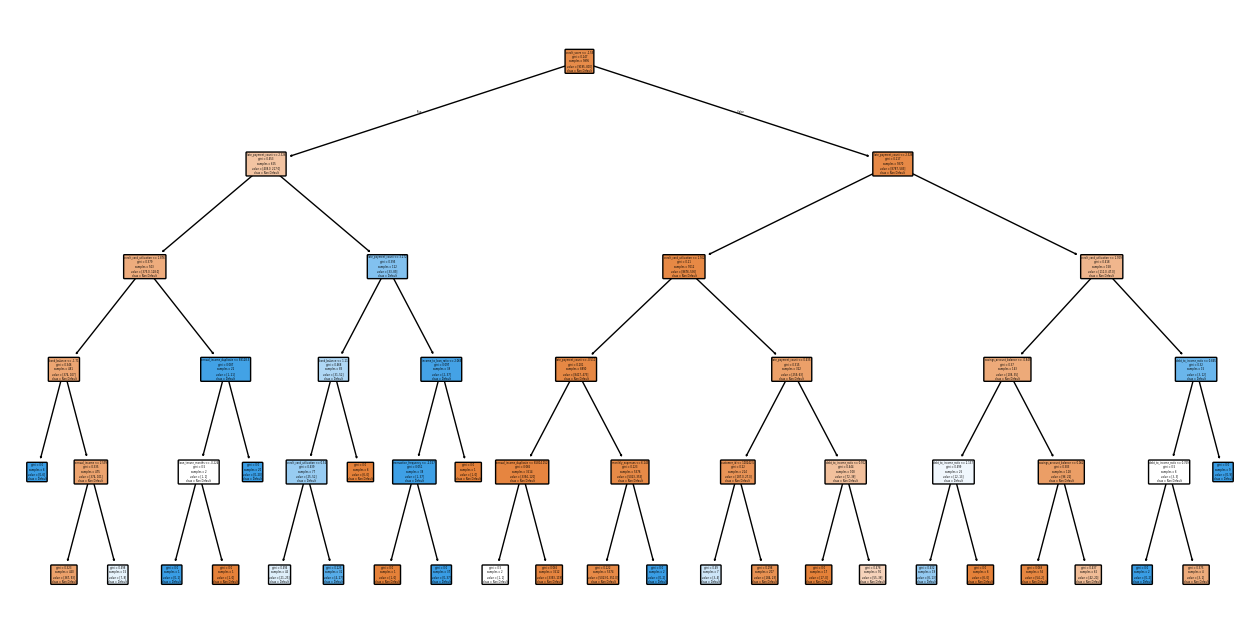

In [53]:
# Plot tree
plt.figure(figsize=(16, 8))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Non-Default", "Default"],
    filled=True,
    rounded=True
)

plt.show()

In [54]:
# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb.fit(X, y)

importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
late_payment_count,0.176069
credit_score,0.088761
credit_card_utilization,0.052870
loan_tenure_months,0.046469
bank_balance,0.045650
income_to_loan_ratio,0.045442
annual_income,0.044403
annual_income_duplicate,0.044015
existing_loans_count,0.043336
interest_rate,0.042995


**How do tree-based models calculate feature importance?**
- Tree-based models measure feature importance based on how much each feature reduces impurity (or improves the split) across all trees.

**Why are embedded methods faster than wrapper methods?**
- Embedded methods perform feature selection during model training, whereas wrapper methods repeatedly train the model on different feature subsets, making them more computationally expensive.

### **Task G4: Metaheuristic-Based Feature Selection**

**Genetic Algorithm**
- Represents feature subsets as chromosomes and uses selection, crossover, and mutation to evolve the best subset based on model performance.

**Simulated Annealing**
- Starts with an initial feature subset and iteratively explores new subsets, occasionally accepting worse solutions to escape local optima and find a better feature set.

---


## **Section H: Final Model Building and Evaluation**

In [60]:
# Models
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Data Visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

Ridge Classifier
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1834
           1       0.00      0.00      0.00       165

    accuracy                           0.92      1999
   macro avg       0.46      0.50      0.48      1999
weighted avg       0.84      0.92      0.88      1999



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


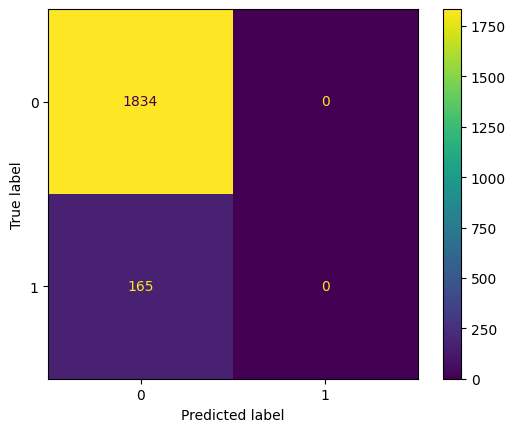

In [61]:
# Ridge Classifier
ridge = RidgeClassifier(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Classifier")
print(classification_report(y_test, y_pred_ridge))

cm = confusion_matrix(y_test, y_pred_ridge)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Random Forest
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1834
           1       0.73      0.12      0.20       165

    accuracy                           0.92      1999
   macro avg       0.83      0.56      0.58      1999
weighted avg       0.91      0.92      0.90      1999



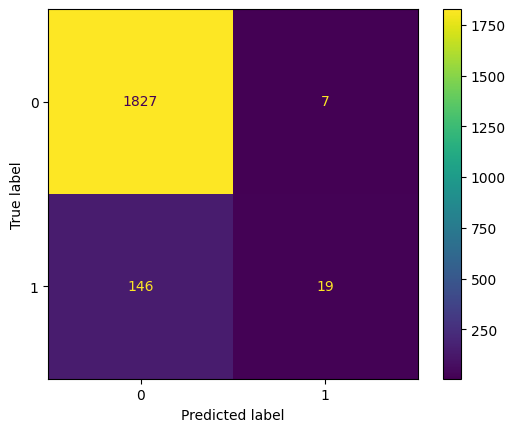

In [62]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [63]:
# Compare two models
comparison = pd.DataFrame({
    "Model": ["Ridge Classifier", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_ridge),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_ridge),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_ridge),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_ridge),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison = comparison.round(4)
comparison

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Ridge Classifier,0.9175,0.0000,0.0000,0.000
1,Random Forest,0.9235,0.7308,0.1152,0.199


### **Model Evaluation**

- Ridge Classifier is fast and performs well with regularization.
- Random Forest captures complex patterns using multiple decision trees.
- A Confusion Matrix evaluates the model using True Positives, True Negatives, False Positives, and False Negatives instead of relying only on accuracy.